In [1]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

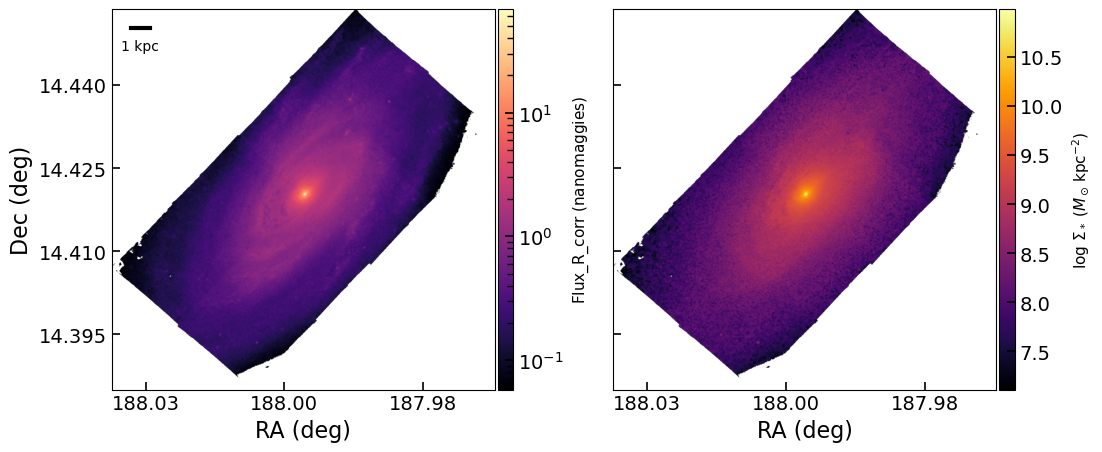

In [2]:
# ----------------------------------------------------------------------
# Side-by-side figure from SPATIAL maps: Flux_R_corr and LOGMASS_SURFACE_DENSITY
# ----------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']


def load_spatial_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'

    if not Path(spatial_path).exists():
        raise FileNotFoundError(f'Required FITS file for {gal} not found: {spatial_path}')

    with fits.open(spatial_path) as h_spatial:
        if 'Flux_R_corr' not in h_spatial:
            available = [hdu.name for hdu in h_spatial]
            raise KeyError(f"'Flux_R_corr' not found for {gal}. Available: {available}")
        if 'LOGMASS_SURFACE_DENSITY' not in h_spatial:
            available = [hdu.name for hdu in h_spatial]
            raise KeyError(f"'LOGMASS_SURFACE_DENSITY' not found for {gal}. Available: {available}")

        flux_r_corr = h_spatial['Flux_R_corr'].data
        logmass_surface_density = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        spatial_header = h_spatial['LOGMASS_SURFACE_DENSITY'].header

    return flux_r_corr, logmass_surface_density, spatial_header


def add_scalebar(ax, length_deg, label='1 kpc'):
    x0, x1 = ax.get_xlim()
    x_range = abs(x1 - x0)
    if x_range == 0:
        return
    frac_len = length_deg / x_range
    x_start = 0.05
    y_start = 0.95
    x_end = x_start + frac_len
    line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                    color='k', lw=3, clip_on=False)
    line.set_in_layout(False)
    txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                  transform=ax.transAxes, ha='center', va='top', color='k')
    txt.set_in_layout(False)


for gal in galaxies:
    flux_r_corr, logmass_surface_density, spatial_header = load_spatial_maps(gal)

    # Coordinate extent
    wcs_celestial = WCS(spatial_header).celestial
    y_size, x_size = flux_r_corr.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # Scale bar: 1 kpc at 16.5 Mpc
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    # Color limits
    valid_flux_pos = np.isfinite(flux_r_corr) & (flux_r_corr > 0)
    valid_logmass = np.isfinite(logmass_surface_density)

    if np.any(valid_flux_pos):
        flux_vmin, flux_vmax = np.nanpercentile(flux_r_corr[valid_flux_pos], [0, 100])
    else:
        raise ValueError(f'No positive finite Flux_R_corr values available for {gal} to use LogNorm.')

    if np.any(valid_logmass):
        mass_vmin, mass_vmax = np.nanpercentile(logmass_surface_density[valid_logmass], [0, 100])
    else:
        mass_vmin, mass_vmax = 0, 1

    # Figure geometry from map aspect
    dx = abs(extent[1] - extent[0])
    dy = abs(extent[3] - extent[2])
    data_ratio = (dx / dy) if dy > 0 else 1.0

    panel_h = 4.6
    panel_w = panel_h * data_ratio
    W = 2 * panel_w + 1.0
    H = panel_h + 0.6

    fig, axs = plt.subplots(1, 2, figsize=(W, H), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.07, right=0.95, bottom=0.12, top=0.96, wspace=0.25)

    ax1, ax2 = axs

    def add_cbar(ax, im, label, size='4.0%', pad=0.03, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    for ax in (ax1, ax2):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    ax2.tick_params(labelleft=False)

    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)

    # Panel 1: Flux_R_corr map (log color scale)
    im_flux = ax1.imshow(
        np.ma.masked_invalid(flux_r_corr),
        origin='lower', cmap='magma',
        extent=extent, norm=LogNorm(vmin=flux_vmin, vmax=flux_vmax),
        aspect='equal'
    )
    add_scalebar(ax1, scalebar_length_deg, label='1 kpc')
    add_cbar(ax1, im_flux, r'$\mathrm{Flux\_R\_corr}\;(\mathrm{nanomaggies})$')

    # Panel 2: LOGMASS_SURFACE_DENSITY map
    im_mass = ax2.imshow(
        np.ma.masked_invalid(logmass_surface_density),
        origin='lower', cmap='inferno',
        extent=extent, vmin=mass_vmin, vmax=mass_vmax,
        aspect='equal'
    )
    add_cbar(ax2, im_mass, r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$')

    output_dir = Path('NGC4501_plots')
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / f'{gal}_FluxRcorr_LOGMASS_maps.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
    fig.savefig(output_dir / f'{gal}_FluxRcorr_LOGMASS_maps.pdf', bbox_inches='tight', pad_inches=0.02)

    plt.show()

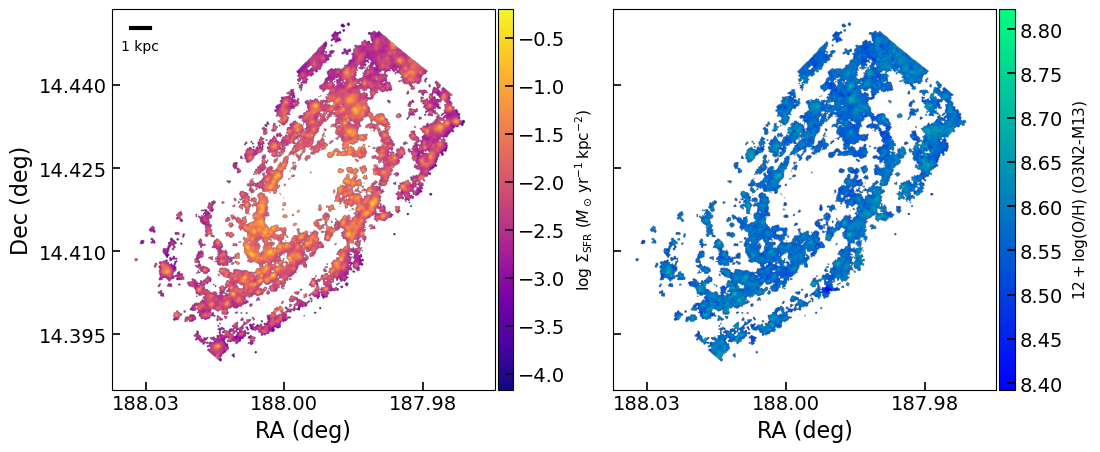

In [3]:
# --------------------------------------------------------------
# Side-by-side figure: raw SFR map and raw [O/H] map (no delta)
# --------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']


def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        _ = h_spatial['LOGMASS_SURFACE_DENSITY'].data

    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")

        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header

    return sigSFR, oh_map, indicator_name, gas_header


def add_scalebar(ax, length_deg, label='1 kpc'):
    x0, x1 = ax.get_xlim()
    x_range = abs(x1 - x0)
    if x_range == 0:
        return
    frac_len = length_deg / x_range
    x_start = 0.05
    y_start = 0.95
    x_end = x_start + frac_len
    line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                    color='k', lw=3, clip_on=False)
    line.set_in_layout(False)
    txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                  transform=ax.transAxes, ha='center', va='top', color='k')
    txt.set_in_layout(False)


for gal in galaxies:
    sigSFR, oh_o3n2_map, indicator_name, gas_header = load_maps(gal)

    # Coordinate extent
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    # Robust color limits
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)

    if np.any(valid_sfr):
        sfr_vmin, sfr_vmax = np.nanpercentile(sigSFR[valid_sfr], [0, 100])
    else:
        sfr_vmin, sfr_vmax = 0, 1

    if np.any(valid_oh):
        oh_vmin, oh_vmax = np.nanpercentile(oh_o3n2_map[valid_oh], [0, 100])
    else:
        oh_vmin, oh_vmax = 0, 1

    # Figure geometry from map aspect
    dx = abs(extent[1] - extent[0])
    dy = abs(extent[3] - extent[2])
    data_ratio = (dx / dy) if dy > 0 else 1.0

    panel_h = 4.6
    panel_w = panel_h * data_ratio
    W = 2 * panel_w + 1.0
    H = panel_h + 0.6

    fig, axs = plt.subplots(1, 2, figsize=(W, H), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.07, right=0.95, bottom=0.12, top=0.96, wspace=0.25)

    ax1, ax2 = axs

    def add_cbar(ax, im, label, size='4.0%', pad=0.03, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    for ax in (ax1, ax2):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    ax2.tick_params(labelleft=False)

    ax1.set_xlabel('RA (deg)', fontsize=16)
    ax2.set_xlabel('RA (deg)', fontsize=16)
    ax1.set_ylabel('Dec (deg)', fontsize=16)

    # Panel 1: raw SFR map
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sigSFR),
        origin='lower', cmap='plasma',
        extent=extent, vmin=sfr_vmin, vmax=sfr_vmax,
        aspect='equal'
    )
    add_scalebar(ax1, scalebar_length_deg, label='1 kpc')
    add_cbar(ax1, im_sfr, r'$\log\,\Sigma_{\mathrm{SFR}}\;(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$')

    # Panel 2: raw [O/H] map
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_o3n2_map),
        origin='lower', cmap='winter',
        extent=extent, vmin=oh_vmin, vmax=oh_vmax,
        aspect='equal'
    )
    add_cbar(ax2, im_oh, rf'$12 + \log(\mathrm{{O/H}})$ ({indicator_name})')

    output_dir = Path('NGC4501_plots')
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / f'{gal}_SFR_OH_maps.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
    fig.savefig(output_dir / f'{gal}_SFR_OH_maps.pdf', bbox_inches='tight', pad_inches=0.02)

    plt.show()

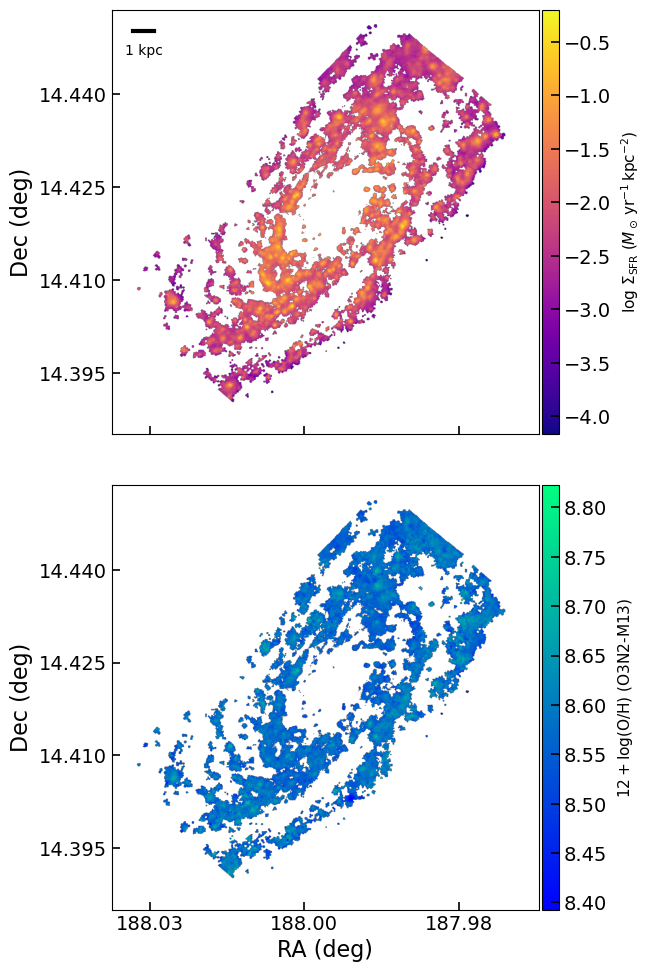

In [4]:
# --------------------------------------------------------------
# Side-by-side figure: raw SFR map and raw [O/H] map (no delta)
# --------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Only focus on NGC4501 for this visualisation
galaxies = ['NGC4501']


def load_maps(gal):
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        _ = h_spatial['LOGMASS_SURFACE_DENSITY'].data

    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        if 'O_H_O3N2_M14_HII' in h_gas:
            oh_map = h_gas['O_H_O3N2_M14_HII'].data
            indicator_name = 'O3N2-M14'
        elif 'O_H_O3N2_M13_HII' in h_gas:
            print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
            indicator_name = 'O3N2-M13'
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")

        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header

    return sigSFR, oh_map, indicator_name, gas_header


def add_scalebar(ax, length_deg, label='1 kpc'):
    x0, x1 = ax.get_xlim()
    x_range = abs(x1 - x0)
    if x_range == 0:
        return
    frac_len = length_deg / x_range
    x_start = 0.05
    y_start = 0.95
    x_end = x_start + frac_len
    line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                    color='k', lw=3, clip_on=False)
    line.set_in_layout(False)
    txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                  transform=ax.transAxes, ha='center', va='top', color='k')
    txt.set_in_layout(False)


for gal in galaxies:
    sigSFR, oh_o3n2_map, indicator_name, gas_header = load_maps(gal)

    # Coordinate extent
    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    x_coords = np.arange(x_size)
    y_coords = np.arange(y_size)
    xx, yy = np.meshgrid(x_coords, y_coords)
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    # Scale bar: 1 kpc for 0.2 arcsec/pixel at 16.5 Mpc
    distance_mpc = 16.5
    kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
    scalebar_length_deg = kpc_arcsec / 3600.0

    # Robust color limits
    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)

    if np.any(valid_sfr):
        sfr_vmin, sfr_vmax = np.nanpercentile(sigSFR[valid_sfr], [0, 100])
    else:
        sfr_vmin, sfr_vmax = 0, 1

    if np.any(valid_oh):
        oh_vmin, oh_vmax = np.nanpercentile(oh_o3n2_map[valid_oh], [0, 100])
    else:
        oh_vmin, oh_vmax = 0, 1

    # Figure geometry from map aspect
    dx = abs(extent[1] - extent[0])
    dy = abs(extent[3] - extent[2])
    data_ratio = (dx / dy) if dy > 0 else 1.0

    panel_h = 4.6
    panel_w = panel_h * data_ratio
    W = panel_w + 0.9
    H = 2 * panel_h + 0.8

    fig, axs = plt.subplots(2, 1, figsize=(W, H), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.10, right=0.93, bottom=0.07, top=0.97, hspace=0.12)

    ax1, ax2 = axs

    def add_cbar(ax, im, label, size='4.0%', pad=0.03, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes('right', size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    for ax in (ax1, ax2):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    ax1.tick_params(labelbottom=False)

    ax1.set_ylabel('Dec (deg)', fontsize=16)
    ax2.set_ylabel('Dec (deg)', fontsize=16)
    ax2.set_xlabel('RA (deg)', fontsize=16)

    # Panel 1: raw SFR map
    im_sfr = ax1.imshow(
        np.ma.masked_invalid(sigSFR),
        origin='lower', cmap='plasma',
        extent=extent, vmin=sfr_vmin, vmax=sfr_vmax,
        aspect='equal'
    )
    add_scalebar(ax1, scalebar_length_deg, label='1 kpc')
    add_cbar(ax1, im_sfr, r'$\log\,\Sigma_{\mathrm{SFR}}\;(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$')

    # Panel 2: raw [O/H] map
    im_oh = ax2.imshow(
        np.ma.masked_invalid(oh_o3n2_map),
        origin='lower', cmap='winter',
        extent=extent, vmin=oh_vmin, vmax=oh_vmax,
        aspect='equal'
    )
    add_cbar(ax2, im_oh, rf'$12 + \log(\mathrm{{O/H}})$ ({indicator_name})')

    output_dir = Path('NGC4501_plots')
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_dir / f'{gal}_SFR_OH_maps_vertical.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
    fig.savefig(output_dir / f'{gal}_SFR_OH_maps_vertical.pdf', bbox_inches='tight', pad_inches=0.02)

    plt.show()

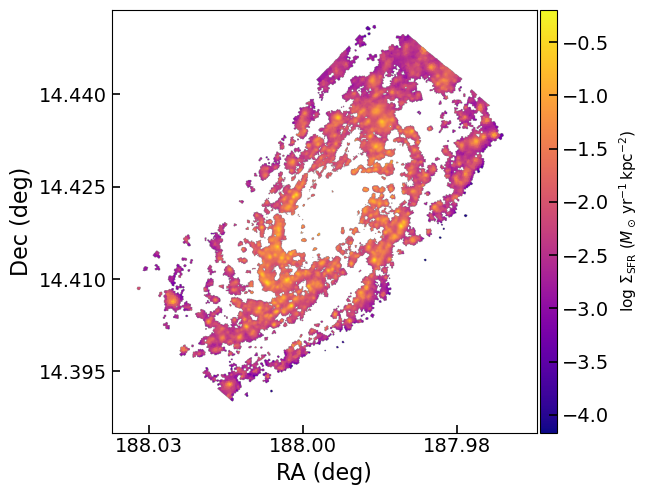

In [5]:
# --------------------------------------------------------------
# Single-panel figure: raw SFR map only (plasma colormap)
# --------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

gal = 'NGC4501'
gas_path = Path(f'{gal}_gas_BIN_maps_extended.fits')

if not gas_path.exists():
    raise FileNotFoundError(f'Required FITS file not found: {gas_path}')

with fits.open(gas_path) as h_gas:
    if 'LOGSFR_SURFACE_DENSITY_HII' not in h_gas:
        available = [hdu.name for hdu in h_gas]
        raise KeyError(f"'LOGSFR_SURFACE_DENSITY_HII' not found. Available: {available}")

    sfr_map = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
    gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header

# Coordinate extent from WCS
wcs_celestial = WCS(gas_header).celestial
y_size, x_size = sfr_map.shape
xx, yy = np.meshgrid(np.arange(x_size), np.arange(y_size))
ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
extent = [ra.max(), ra.min(), dec.min(), dec.max()]

# Color limits
valid_sfr = np.isfinite(sfr_map)
if np.any(valid_sfr):
    sfr_vmin, sfr_vmax = np.nanpercentile(sfr_map[valid_sfr], [0, 100])
else:
    sfr_vmin, sfr_vmax = 0, 1

# Figure geometry from map aspect
dx = abs(extent[1] - extent[0])
dy = abs(extent[3] - extent[2])
data_ratio = (dx / dy) if dy > 0 else 1.0
panel_h = 4.8
panel_w = panel_h * data_ratio

fig, ax = plt.subplots(figsize=(panel_w + 0.6, panel_h + 0.3))

im_sfr = ax.imshow(
    np.ma.masked_invalid(sfr_map),
    origin='lower',
    cmap='plasma',
    extent=extent,
    vmin=sfr_vmin,
    vmax=sfr_vmax,
    aspect='equal'
)

ax.set_xlabel('RA (deg)', fontsize=16)
ax.set_ylabel('Dec (deg)', fontsize=16)
ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='4.0%', pad=0.03)
cbar = fig.colorbar(im_sfr, cax=cax)
cbar.set_label(r'$\log\,\Sigma_{\mathrm{SFR}}\;(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=11, labelpad=6)

fig.subplots_adjust(left=0.10, right=0.92, bottom=0.12, top=0.97)

output_dir = Path('NGC4501_plots')
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / f'{gal}_SFR_map.png', dpi=600, bbox_inches='tight', pad_inches=0.02)
fig.savefig(output_dir / f'{gal}_SFR_map.pdf', bbox_inches='tight', pad_inches=0.02)

plt.show()